<a href="https://colab.research.google.com/github/Sancheuz123/KSVD/blob/main/%D0%9B%D0%A0_2%20%D0%93%D0%B0%D0%B9%D0%B2%D0%BE%D1%80%D0%BE%D0%BD%D1%81%D1%8C%D0%BA%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving bestsellers with categories.csv to bestsellers with categories (1).csv


In [ ]:
df = pd.read_csv('bestsellers with categories.csv', encoding= 'latin1')
df

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'amazon-top-50-bestselling-books-2009-2019' dataset.
Path to dataset files: /kaggle/input/amazon-top-50-bestselling-books-2009-2019


In [ ]:
df = pd.read_csv(os.path.join(path, "bestsellers with categories.csv"))

df

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


In [ ]:
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [ ]:
df.shape

(550, 7)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.duplicated(subset='Name').sum()

np.int64(199)

In [ ]:
df = df.drop_duplicates(subset='Name')

In [ ]:
df.shape

(351, 7)

In [ ]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']
df.head()

,name,author,user_rating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 351 entries, 0 to 546
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         351 non-null    object 
 1   author       351 non-null    object 
 2   user_rating  351 non-null    float64
 3   reviews      351 non-null    int64  
 4   price        351 non-null    int64  
 5   year         351 non-null    int64  
 6   genre        351 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 21.9+ KB


In [ ]:
df.isna().sum()

,0
name,0
author,0
user_rating,0
reviews,0
price,0
year,0
genre,0


In [ ]:
df['genre'].value_counts()

,count
genre,
Non Fiction,191
Fiction,160


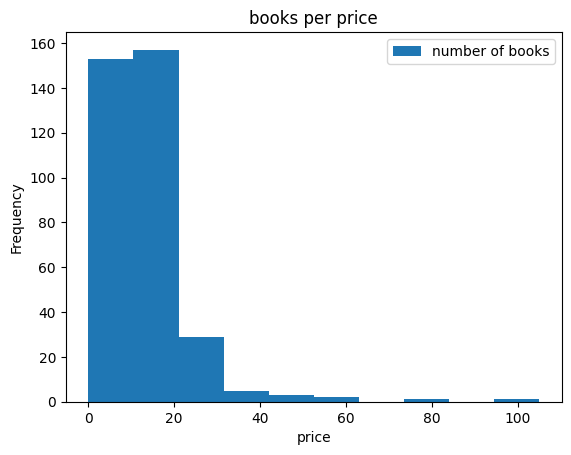

In [ ]:
df['price'].plot(kind='hist', label='number of books')
plt.xlabel('price')
plt.title('books per price')
plt.legend()
plt.show()


In [ ]:
df['price'].describe()

,price
count,351.000000
mean,13.076923
std,10.050860
min,0.000000
25%,8.000000
50%,12.000000
75%,16.000000
max,105.000000


In [ ]:
df['price'].max()

105

In [ ]:
df['price'].min()

0

In [ ]:
df['price'].mean()

np.float64(13.076923076923077)

In [ ]:
df['price'].median()

12.0

In [ ]:
df['user_rating'].max()

4.9

In [ ]:
df[df['user_rating'] == 4.9]['name'].count()

np.int64(28)

In [ ]:
df[df['reviews'] == df['reviews'].max()]

,name,author,user_rating,reviews,price,year,genre
534,Where the Crawdads Sing,Delia Owens,4.8,87841,15,2019,Fiction


In [ ]:
max_price = df[df['year'] == 2015]['price'].max()
df[(df['year'] == 2015) & (df['price'] == max_price)]

,name,author,user_rating,reviews,price,year,genre
132,Go Set a Watchman: A Novel,Harper Lee,3.6,14982,19,2015,Fiction


In [ ]:
df[(df['year'] == 2010) & (df ['genre'] == 'Fiction')].count()['name']

np.int64(17)

In [ ]:
df[ (df['user_rating'] == 4.9) & ((df['year']==2010) | (df['year'] == 2011)) ]

,name,author,user_rating,reviews,price,year,genre
187,Jesus Calling: Enjoying Peace in His Presence ...,Sarah Young,4.9,19576,8,2011,Non Fiction


In [ ]:
df[(df['price'] <8) & (df['year'] == 2015)].sort_values('price')

,name,author,user_rating,reviews,price,year,genre
54,Creative Haven Creative Cats Coloring Book (Ad...,Marjorie Sarnat,4.8,4022,4,2015,Non Fiction
123,Giraffes Can't Dance,Giles Andreae,4.8,14038,4,2015,Fiction
55,Creative Haven Owls Coloring Book (Adult Color...,Marjorie Sarnat,4.8,3871,5,2015,Non Fiction
28,Baby Touch and Feel: Animals,DK,4.6,5360,5,2015,Non Fiction
63,Dear Zoo: A Lift-the-Flap Book,Rod Campbell,4.8,10922,5,2015,Fiction
89,Dover Creative Haven Art Nouveau Animal Design...,Marty Noble,4.6,2134,5,2015,Non Fiction
201,Killing Reagan: The Violent Assault That Chang...,Bill O'Reilly,4.6,5235,5,2015,Non Fiction
16,Adult Coloring Book: Stress Relieving Animal D...,Blue Star Coloring,4.6,2925,6,2015,Non Fiction
17,Adult Coloring Book: Stress Relieving Patterns,Blue Star Coloring,4.4,2951,6,2015,Non Fiction
253,Old School (Diary of a Wimpy Kid #10),Jeff Kinney,4.8,6169,7,2015,Fiction


In [ ]:
df.groupby(['genre']) [['price']].agg([np.min, np.max])

/tmp/ipykernel_4518/2271838630.py:1: FutureWarning: The provided callable <function min at 0x7e4056134f40> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df.groupby(['genre']) [['price']].agg([np.min, np.max])
/tmp/ipykernel_4518/2271838630.py:1: FutureWarning: The provided callable <function max at 0x7e4056134e00> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df.groupby(['genre']) [['price']].agg([np.min, np.max])


price     
              min  max
genre                 
Fiction         0   82
Non Fiction     0  105

In [ ]:
author_books = df.groupby(['author'])[['name']].count()
author_books

,name
author,
Abraham Verghese,1
Adam Gasiewski,1
Adam Mansbach,1
Adir Levy,1
Admiral William H. McRaven,1
...,...
Walter Isaacson,2
William Davis,1
William P. Young,1


In [ ]:
author_books [author_books [ 'name' ] == author_books ['name' ]. max() ]

,name
author,
Jeff Kinney,12


In [ ]:
avg_author_raing = df.groupby (['author']) [['user_rating']].agg(np.mean).round(1)
avg_author_raing

/tmp/ipykernel_4518/3410153078.py:1: FutureWarning: The provided callable <function mean at 0x7e4056135800> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  avg_author_raing = df.groupby (['author']) [['user_rating']].agg(np.mean).round(1)


,user_rating
author,
Abraham Verghese,4.6
Adam Gasiewski,4.4
Adam Mansbach,4.8
Adir Levy,4.8
Admiral William H. McRaven,4.7
...,...
Walter Isaacson,4.6
William Davis,4.4
William P. Young,4.6


In [ ]:
avg_author_raing[avg_author_raing['user_rating'] == avg_author_raing['user_rating']. min()]

,user_rating
author,
Donna Tartt,3.9


In [ ]:
avg_author_raing.min()

,0
user_rating,3.9


In [ ]:
book_and_raiting = pd.concat([avg_author_raing, author_books], axis=1)
book_and_raiting

,user_rating,name
author,,
Abraham Verghese,4.6,1
Adam Gasiewski,4.4,1
Adam Mansbach,4.8,1
Adir Levy,4.8,1
Admiral William H. McRaven,4.7,1
...,...,...
Walter Isaacson,4.6,2
William Davis,4.4,1
William P. Young,4.6,1


In [ ]:
book_and_raiting.sort_values(by=['name', 'user_rating'])

,user_rating,name
author,,
Donna Tartt,3.9,1
Gallup,4.0,1
Gillian Flynn,4.0,1
Muriel Barbery,4.0,1
Chris Cleave,4.1,1
...,...,...
Bill O'Reilly,4.6,6
Dav Pilkey,4.9,6
Stephenie Meyer,4.7,7
